## Resources - Guilherme Daflon

Este exercício prático aborda visualização de dados com Matplotlib do nível básico ao intermediário/avançado (gráficos essenciais, personalização visual, API orientada a objetos subplots, eixos duplos twinx, anotações e mapas de calor com imshow).

**Contexto do Problema**
Você atua no time de Business Intelligence e precisa apresentar relatórios visuais sobre o desempenho de vendas de uma rede varejista. Você utilizará um conjunto de dados contendo o histórico de transações com valores, categorias, regiões, estados e datas para construir painéis analíticos claros e informativos.

### Configuração do Ambiente e Dados Iniciais
Execute o bloco abaixo para carregar as bibliotecas e gerar a base de dados simulada para a atividade:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)

display(df.head())

,data,categoria,estado,valor,quantidade,valor_venda
0,2024-01-01,Roupas,BA,2228.06,13,2182.83
1,2024-01-02,Automotivo,RJ,4436.14,12,4538.93
2,2024-01-03,Eletronicos,BA,1127.15,10,1157.60
3,2024-01-04,Roupas,RJ,3041.00,7,2764.45
4,2024-01-05,Roupas,SP,3439.21,9,3352.96


### Parte 1: Gráficos Essenciais e Personalização (Básico)

#### 1. Gráfico de linha do faturamento mensal total

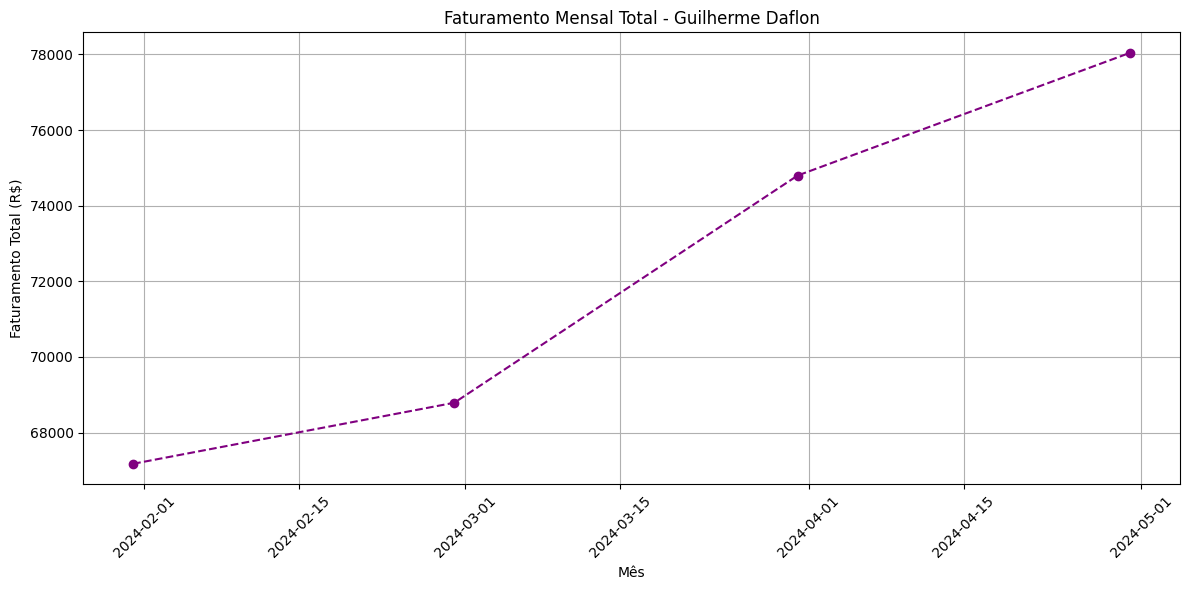

In [12]:
# 1. Construa um gráfico de linha (plt.plot ou ax.plot) mostrando o faturamento mensal total (resample('ME')).
#    Adicione marcadores circulares ('o'), linha tracejada ('--'), cor customizada, grade (grid) e rótulos para os eixos X e Y.

df_monthly = df.set_index('data').resample('ME')['valor_venda'].sum()

plt.figure(figsize=(12, 6))
plt.plot(df_monthly.index, df_monthly.values, marker='o', linestyle='--', color='purple')
plt.grid(True)
plt.xlabel('Mês')
plt.ylabel('Faturamento Total (R$)')
plt.title('Faturamento Mensal Total - Guilherme Daflon')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 2. Gráfico de barras com o total de vendas por categoria

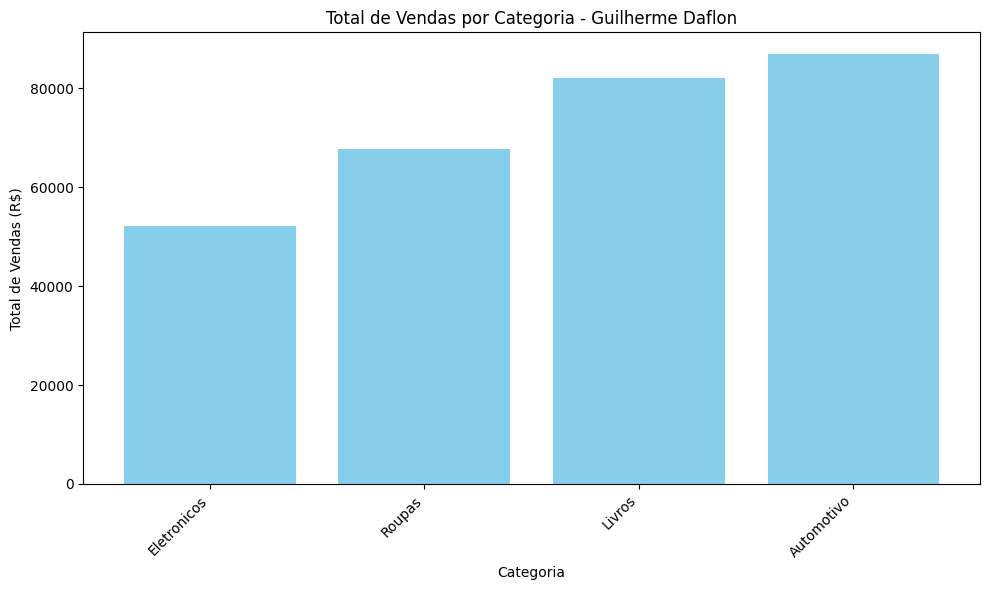

In [13]:
# 2. Crie um gráfico de barras (plt.bar) com o total de vendas por categoria ordenado do menor para o maior valor,
#    rotacionando os rótulos do eixo X em 45 graus.

sales_by_category = df.groupby('categoria')['valor_venda'].sum().sort_values()

plt.figure(figsize=(10, 6))
plt.bar(sales_by_category.index, sales_by_category.values, color='skyblue')
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas (R$)')
plt.title('Total de Vendas por Categoria - Guilherme Daflon')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### 3. Histograma da coluna `valor`

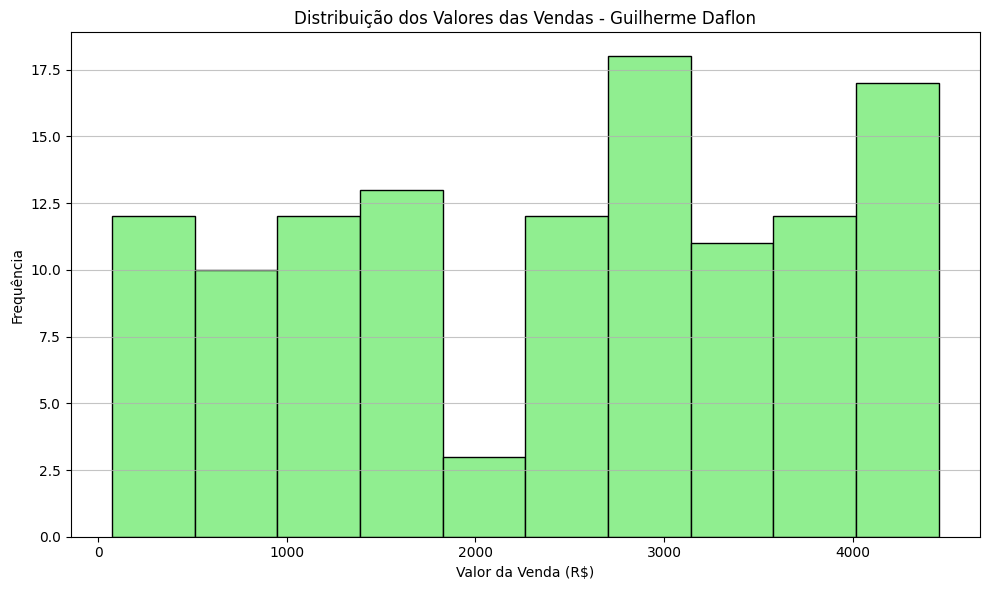

In [14]:
# 3. Crie um histograma (plt.hist) da coluna valor com 10 bins e bordas destacadas (edgecolor='black')
#    para analisar a distribuição dos valores das vendas.

plt.figure(figsize=(10, 6))
plt.hist(df['valor'], bins=10, edgecolor='black', color='lightgreen')
plt.xlabel('Valor da Venda (R$)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Valores das Vendas - Guilherme Daflon')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Parte 2: API Orientada a Objetos e Eixos Múltiplos (Intermediário)

#### 4. Grade 2x1 de subplots com faturamento mensal e quantidade de itens vendidos

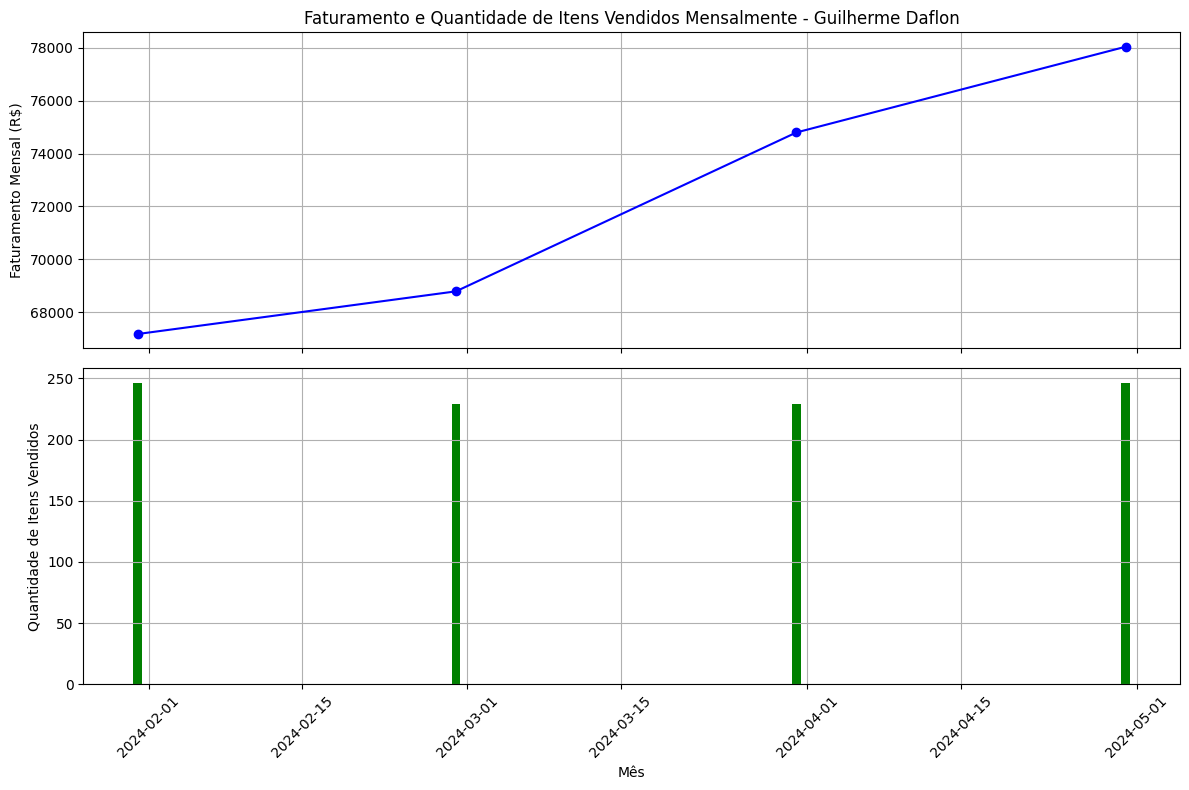

In [15]:
# 4. Crie uma figura com uma grade 2 x 1 de subplots (fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True))
#    com o eixo X compartilhado:
#    ax1 (Superior): Gráfico de linha com o faturamento mensal.
#    ax2 (Inferior): Gráfico de barras com a quantidade total de itens vendidos no mesmo período.

df_monthly_agg = df.set_index('data').resample('ME').agg({
    'valor_venda': 'sum',
    'quantidade': 'sum'
})

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

# Subplot Superior (ax1): Faturamento Mensal
ax1.plot(df_monthly_agg.index, df_monthly_agg['valor_venda'], marker='o', linestyle='-', color='blue')
ax1.set_ylabel('Faturamento Mensal (R$)')
ax1.set_title('Faturamento e Quantidade de Itens Vendidos Mensalmente - Guilherme Daflon')
ax1.grid(True)

# Subplot Inferior (ax2): Quantidade Total de Itens Vendidos
ax2.bar(df_monthly_agg.index, df_monthly_agg['quantidade'], color='green')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade de Itens Vendidos')
ax2.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 5. Gráfico com dois eixos Y (TwinX) para valor total e quantidade média por venda

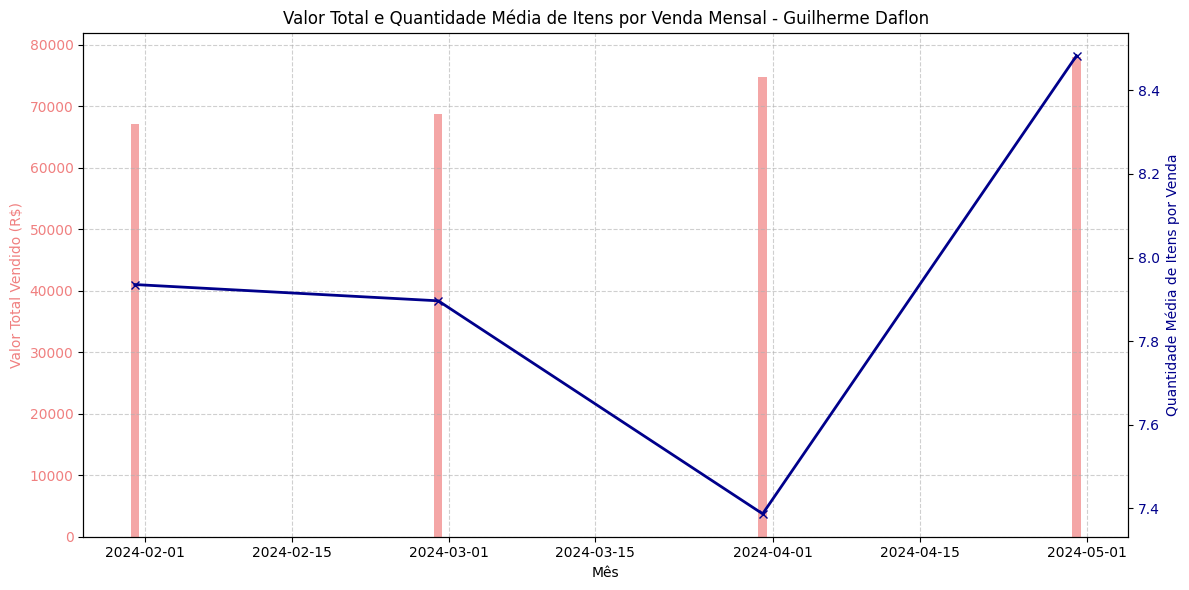

In [16]:
# 5. Crie um gráfico com dois eixos Y (ax.twinx()):
#    No eixo primário (à esquerda), exiba o valor total vendido por mês em barras.
#    No eixo secundário (à direita), plote a quantidade média de itens por venda em linha com marcadores.

df_monthly_avg_qty = df.set_index('data').resample('ME').agg({
    'valor_venda': 'sum',
    'quantidade': 'mean' # Média de itens por venda no mês
})

fig, ax1 = plt.subplots(figsize=(12, 6))

# Eixo Primário (ax1): Valor Total Vendido por Mês (Barras)
ax1.bar(df_monthly_avg_qty.index, df_monthly_avg_qty['valor_venda'], color='lightcoral', alpha=0.7, label='Valor Total Vendido')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Valor Total Vendido (R$)', color='lightcoral')
ax1.tick_params(axis='y', labelcolor='lightcoral')
ax1.grid(True, linestyle='--', alpha=0.6)

# Eixo Secundário (ax2): Quantidade Média de Itens por Venda (Linha)
ax2 = ax1.twinx()
ax2.plot(df_monthly_avg_qty.index, df_monthly_avg_qty['quantidade'], color='darkblue', marker='x', linestyle='-', linewidth=2, label='Quantidade Média de Itens por Venda')
ax2.set_ylabel('Quantidade Média de Itens por Venda', color='darkblue')
ax2.tick_params(axis='y', labelcolor='darkblue')

plt.title('Valor Total e Quantidade Média de Itens por Venda Mensal - Guilherme Daflon')
fig.tight_layout()
plt.xticks(rotation=45)
plt.show()

#### 6. Anotação do mês de maior faturamento no gráfico de linha mensal

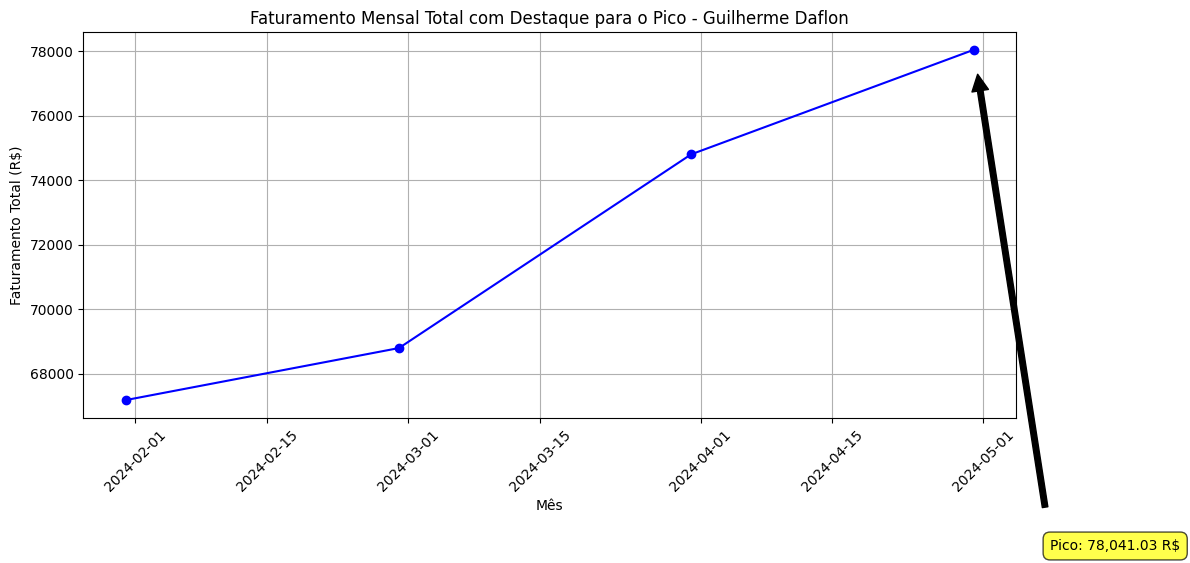

In [17]:
# 6. No gráfico de linha mensal, identifique o mês de maior faturamento e adicione uma anotação com seta apontando para o pico usando ax.annotate().

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_monthly.index, df_monthly.values, marker='o', linestyle='-', color='blue', label='Faturamento Mensal')
ax.grid(True)
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento Total (R$)')
ax.set_title('Faturamento Mensal Total com Destaque para o Pico - Guilherme Daflon')
ax.tick_params(axis='x', rotation=45)

# Identificar o mês de maior faturamento
max_revenue_month = df_monthly.idxmax()
max_revenue_value = df_monthly.max()

# Adicionar anotação
ax.annotate(f'Pico: {max_revenue_value:,.2f} R$',
            xy=(max_revenue_month, max_revenue_value),
            xytext=(max_revenue_month + pd.DateOffset(days=15), max_revenue_value * 0.8),
            arrowprops=dict(facecolor='black', shrink=0.05),
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', fc='yellow', ec='k', lw=1, alpha=0.7))

plt.tight_layout()
plt.show()

### Parte 3: Matriz de Intensidade / Heatmap (Intermediário / Avançado)

#### 7. Construção da tabela dinâmica

In [8]:
# 7. Construa uma tabela dinâmica (pd.pivot_table) somando os valores de venda agrupados por categoria nas linhas e estado nas colunas.

pivot_table = df.pivot_table(values='valor_venda', index='categoria', columns='estado', aggfunc='sum', fill_value=0)

display(pivot_table)

estado,BA,MG,RJ,RS,SP
categoria,,,,,
Automotivo,6992.96,16333.39,26783.38,10122.88,26727.57
Eletronicos,14211.94,13453.06,1154.47,13966.62,9372.80
Livros,4318.03,25667.11,9659.57,19302.59,23104.72
Roupas,26968.88,9876.74,11120.83,4809.04,14856.77


#### 8. Renderização do Heatmap

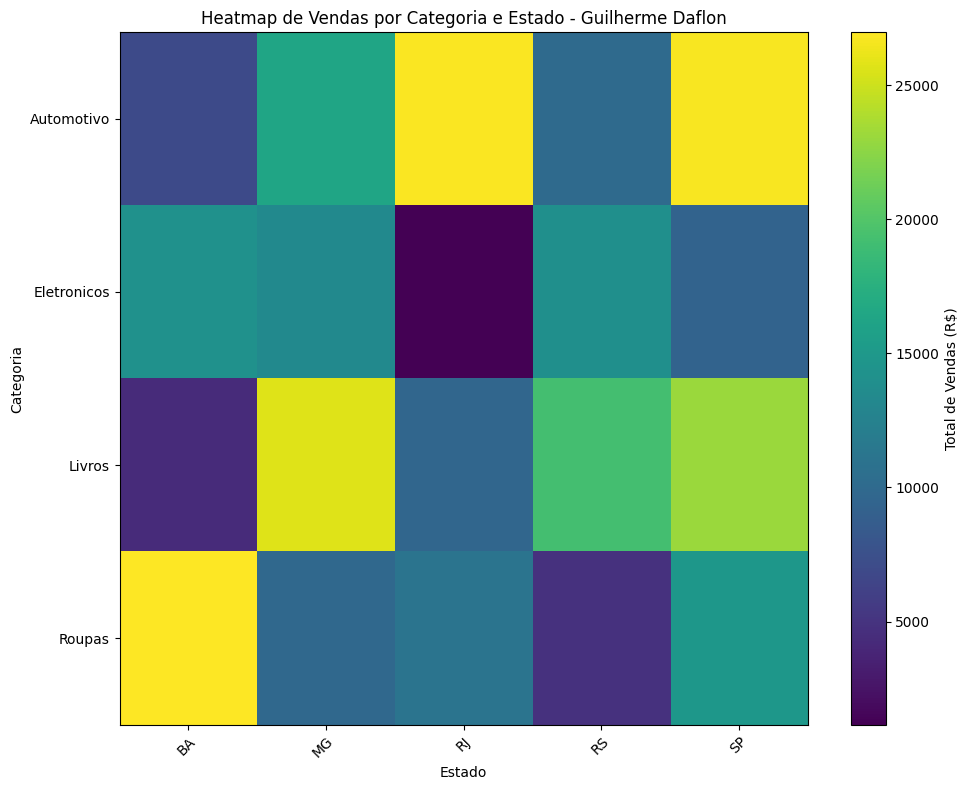

In [18]:
# 8. Renderize essa matriz na forma de um Heatmap utilizando plt.imshow(), incluindo uma barra de cores (plt.colorbar())
#    e os respectivos rótulos nominais nas marcações dos eixos X (xticks) e Y (yticks).

fig_heatmap, ax_heatmap = plt.subplots(figsize=(10, 8))

# Usando imshow para criar o heatmap
cmap = ax_heatmap.imshow(pivot_table, cmap='viridis', aspect='auto')

# Adicionar barra de cores
plt.colorbar(cmap, ax=ax_heatmap, label='Total de Vendas (R$)')

# Configurar rótulos dos eixos X e Y
ax_heatmap.set_xticks(np.arange(len(pivot_table.columns)))
ax_heatmap.set_yticks(np.arange(len(pivot_table.index)))
ax_heatmap.set_xticklabels(pivot_table.columns)
ax_heatmap.set_yticklabels(pivot_table.index)

# Rotação dos rótulos do eixo X para melhor legibilidade
plt.setp(ax_heatmap.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

ax_heatmap.set_xlabel('Estado')
ax_heatmap.set_ylabel('Categoria')
ax_heatmap.set_title('Heatmap de Vendas por Categoria e Estado - Guilherme Daflon')

plt.tight_layout()
plt.show()

#### 9. Salvar a figura do Heatmap

Heatmap salvo como 'heatmap_vendas.png'


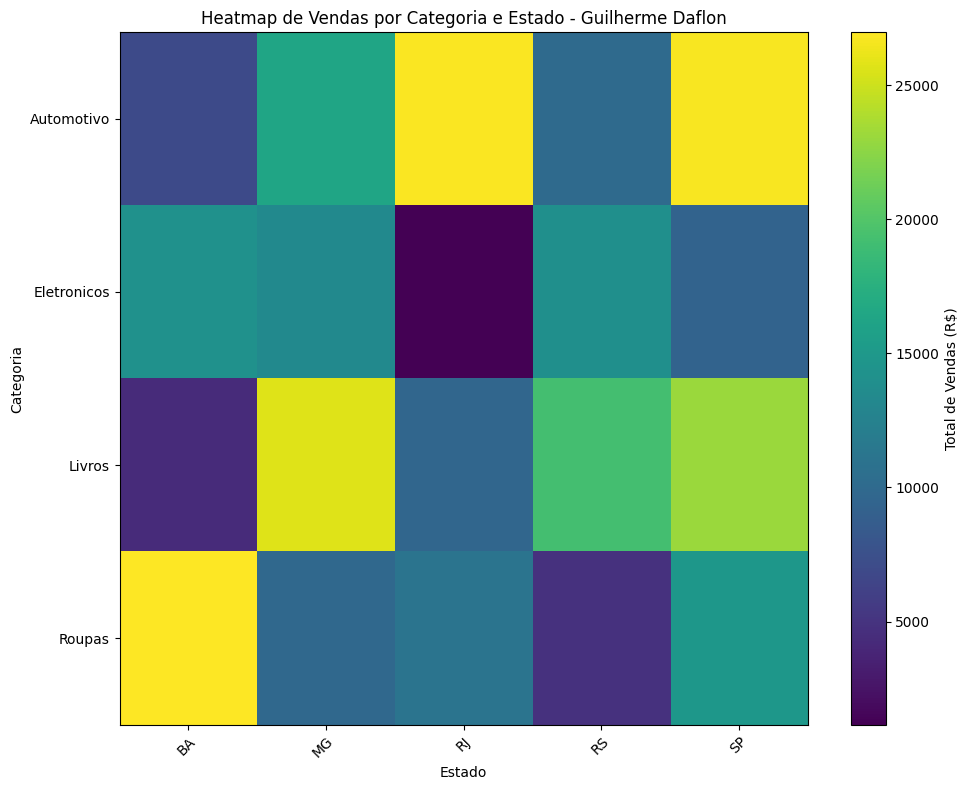

In [19]:
# 9. Salve a figura gerada no passo 8 em um arquivo de imagem 'heatmap_vendas.png' com resolução de 300 DPI e corte ajustado (bbox_inches='tight').

# Recriar a figura do heatmap para garantir que seja salva corretamente (se a anterior já foi fechada)
fig_heatmap_save, ax_heatmap_save = plt.subplots(figsize=(10, 8))

cmap_save = ax_heatmap_save.imshow(pivot_table, cmap='viridis', aspect='auto')

plt.colorbar(cmap_save, ax=ax_heatmap_save, label='Total de Vendas (R$)')

ax_heatmap_save.set_xticks(np.arange(len(pivot_table.columns)))
ax_heatmap_save.set_yticks(np.arange(len(pivot_table.index)))
ax_heatmap_save.set_xticklabels(pivot_table.columns)
ax_heatmap_save.set_yticklabels(pivot_table.index)

plt.setp(ax_heatmap_save.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

ax_heatmap_save.set_xlabel('Estado')
ax_heatmap_save.set_ylabel('Categoria')
ax_heatmap_save.set_title('Heatmap de Vendas por Categoria e Estado - Guilherme Daflon')

plt.tight_layout()

# Salvar a figura
plt.savefig('heatmap_vendas.png', dpi=300, bbox_inches='tight')
print("Heatmap salvo como 'heatmap_vendas.png'")

plt.show()